<a href="https://colab.research.google.com/github/changsuk-oh/introduction-to-deep-learning/blob/main/4%EC%9E%A5_%EB%B6%84%EB%A5%98%EC%99%80_%ED%9A%8C%EA%B7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

4장 분류와 회귀

In [ ]:
# 예제 4,1 MLP MNIST 분류

# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
torch.manual_seed(7)

In [ ]:
# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 데이터셋 준비/전처리
transform = transforms.ToTensor()   # 텐서 변환/정규화(0 ~ 1)

train_dataset = datasets.MNIST(root="./data", train=True,
                               download=True, transform=transform)

test_dataset = datasets.MNIST(root="./data", train=False,
                              download=True, transform=transform)

print(train_dataset.data.shape)  # 학습 데이터 shape 확인
print(test_dataset.data.shape)  # 테스트 데이터 shape 확인

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


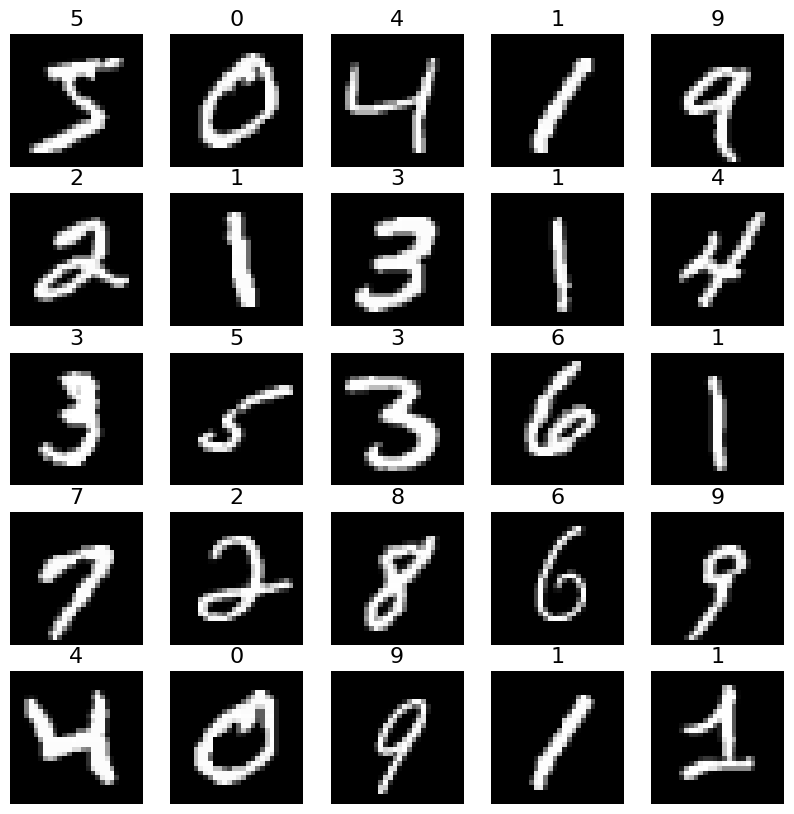

In [ ]:
# 학습 데이터 시각화
plt.figure(figsize=(10, 10))

for i in range(25):
    image, label = train_dataset[i]

    plt.subplot(5, 5, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(label, fontsize=16)
    plt.axis("off")

plt.show()

In [ ]:
# 학습 데이터/검증 데이터 분할
train_size = int(0.8 * len(train_dataset))
valid_size = len(train_dataset) - train_size

train_dataset, valid_dataset = random_split(
    train_dataset, [train_size, valid_size])

In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# 모델 생성
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MNISTModel().to(device)

In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.CrossEntropyLoss()   # 손실 함수로 교차 엔트로피 사용
optimizer = optim.Adam(model.parameters(), lr=0.001)   # 옵티마이저로 Adam 사용

In [ ]:
# 학습 함수 정의
def train_step(model, optimizer, loss_fn, train_loader, device):
    model.train()   # 학습 모드

    train_loss = 0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)   # 출력 계산
        loss = loss_fn(outputs, labels)   # 손실 계산

        optimizer.zero_grad()   # 그레디언트 초기화
        loss.backward()   # 역전파
        optimizer.step()   # 최적화 수행

        train_loss += loss.item() * images.size(0)

        predict = outputs.argmax(dim=1)   # 예측
        correct += (predict == labels).sum().item()   # 정확한 예측

    train_loss /= len(train_loader.dataset)   # 학습 손실
    train_acc = correct / len(train_loader.dataset)   # 학습 정확도

    return train_loss, train_acc

In [ ]:
# 검증 함수 정의
def validation_step(model, loss_fn, valid_loader, device):
    model.eval()   # 평가 모드

    valid_loss = 0
    correct = 0

    with torch.no_grad():   # 검증할 때에는 자동 미분하지 않음
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)   # 출력 계산
            loss = loss_fn(outputs, labels)   # 손실 계산

            valid_loss += loss.item() * images.size(0)

            predict = outputs.argmax(dim=1)   # 예측
            correct += (predict == labels).sum().item()   # 정확한 예측

    valid_loss /= len(valid_loader.dataset)   # 검증 손실
    valid_acc = correct / len(valid_loader.dataset)   # 검증 정확도

    return valid_loss, valid_acc

In [ ]:
# 모델 학습
epochs = 5   # 반복 횟수
train_losses = []   # 학습 손실 리스트
train_accs = []   # 학습 정확도 리스트
valid_losses = []   # 검증 손실 리스트
valid_accs = []   # 검증 정확도 리스트

for epoch in range(epochs):
    train_loss, train_acc = train_step(model, optimizer, loss_fn, train_loader,
                                       device)
    train_losses.append(train_loss)   # 학습 손실 저장(학습 결과 시각화용)
    train_accs.append(train_acc)   # 학습 정확도 저장(학습 결과 시각화용)

    valid_loss, valid_acc = validation_step(model, loss_fn, valid_loader, device)
    valid_losses.append(valid_loss)   # 검증 손실 저장(학습 결과 시각화용)
    valid_accs.append(valid_acc)   # 검증 정확도 저장(학습 결과 시각화용)

    print(f"Epoch {epoch + 1} / {epochs} \n"
          f" - loss: {train_loss:.4f}  - accuracy: {train_acc:.4f}"
          f"  - val_loss: {valid_loss:.4f}  - val_accuracy: {valid_acc:.4f}")

Epoch 1 / 5 
 - loss: 0.3201  - accuracy: 0.9070  - val_loss: 0.1650  - val_accuracy: 0.9523
Epoch 2 / 5 
 - loss: 0.1352  - accuracy: 0.9595  - val_loss: 0.1368  - val_accuracy: 0.9590
Epoch 3 / 5 
 - loss: 0.0940  - accuracy: 0.9709  - val_loss: 0.1101  - val_accuracy: 0.9667
Epoch 4 / 5 
 - loss: 0.0696  - accuracy: 0.9788  - val_loss: 0.1028  - val_accuracy: 0.9693
Epoch 5 / 5 
 - loss: 0.0540  - accuracy: 0.9832  - val_loss: 0.0916  - val_accuracy: 0.9734


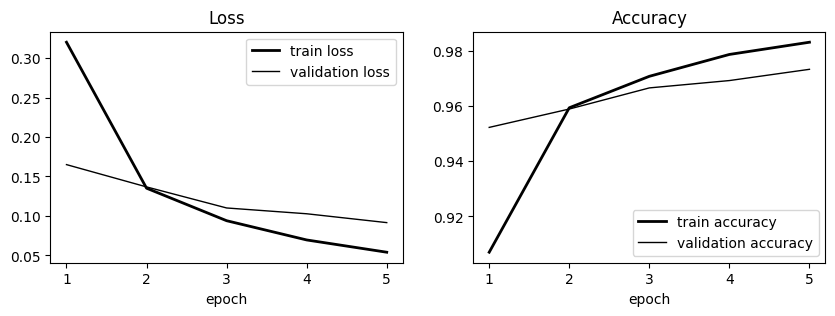

In [ ]:
# 학습 결과 시각화
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label="train loss",
         color='black', linewidth=2)
plt.plot(range(1, epochs + 1), valid_losses, label="validation loss",
         color='black', linewidth=1)
plt.title("Loss")
plt.xlabel("epoch")
plt.legend(loc="best")

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accs, label="train accuracy",
         color='black', linewidth=2)
plt.plot(range(1, epochs + 1), valid_accs, label="validation accuracy",
         color='black', linewidth=1)
plt.title("Accuracy")
plt.xlabel("epoch")
plt.legend(loc="best")

plt.show()

In [ ]:
# 모델 평가
model.eval()   # 평가 모드

correct = 0
actual = []
predicted = []

with torch.no_grad():   # 평가할 때에는 자동 미분하지 않음
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)   # 출력 계산
        predict = outputs.argmax(dim=1)   # 예측
        correct += (predict == labels).sum().item()   # 정확한 예측

        actual.extend(labels.cpu().numpy())   # 실제값 리스트 생성
        predicted.extend(predict.cpu().numpy())   # 예측값 리스트 생성

test_acc = 100 * correct / len(test_loader.dataset)   # 정확도 계산

print(f"Accuracy: {test_acc:.2f}%")

Accuracy: 97.49%


number of samples: [ 980 1135 1032 1010  982  892  958 1028  974 1009] 



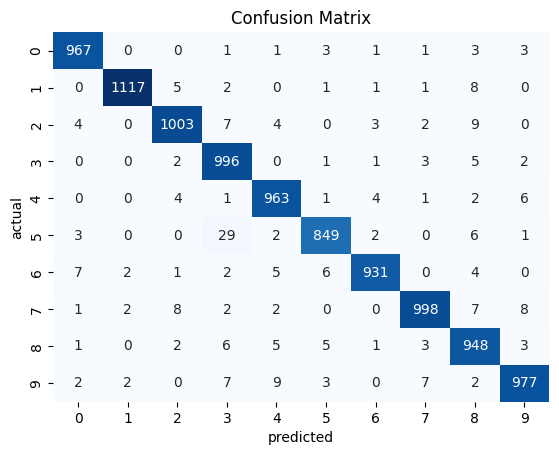

In [ ]:
# 혼동 행렬 시각화
num_labels = np.bincount(actual)   # 클래스별 샘플 수

print(f"number of samples: {num_labels} \n")

cm = confusion_matrix(actual, predicted)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()

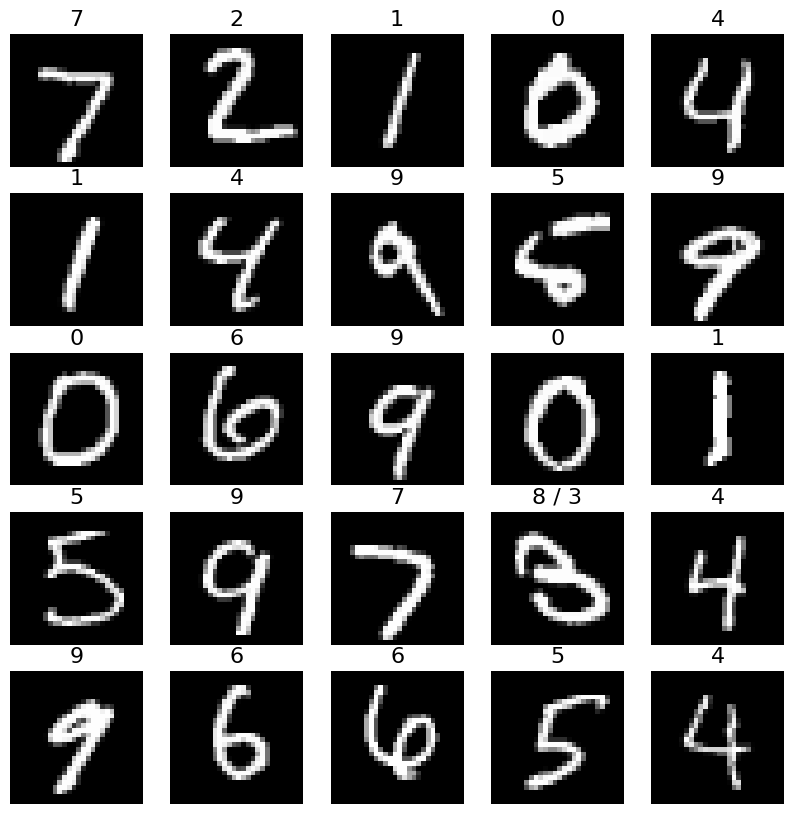

In [ ]:
# 모델 예측 결과 시각화
model.eval()   # 평가 모드

images, labels = next(iter(test_loader))
images = images[:25].to(device)
labels = labels[:25].to(device)

with torch.no_grad():   # 예측할 때에는 자동 미분하지 않음
    outputs = model(images)
    predict = outputs.argmax(dim=1)   # 예측

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    if predict[i] != labels[i]:
        plt.title(f"{predict[i].item()} / {labels[i].item()}", fontsize=16)
    else:
        plt.title(predict[i].item(), fontsize=16)
    plt.axis("off")

plt.show()

In [ ]:
# 오분류 샘플 수집
model.eval()

max_samples = 10
num_classes = 10
misclassified = {i: [] for i in range(num_classes)}

with torch.no_grad():   # 예측할 때에는 자동 미분하지 않음
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        output = model(images)
        predict = output.argmax(dim=1)   # 예측

        wrong_idx = torch.where(predict != labels)[0]   # 오분류 인덱스 추출

        for i in wrong_idx:
            cls = labels[i].item()
            if len(misclassified[cls]) < max_samples:
                misclassified[cls].append((images[i].cpu(), predict[i].item()))

        if all(len(v) >= max_samples for v in misclassified.values()):
            break

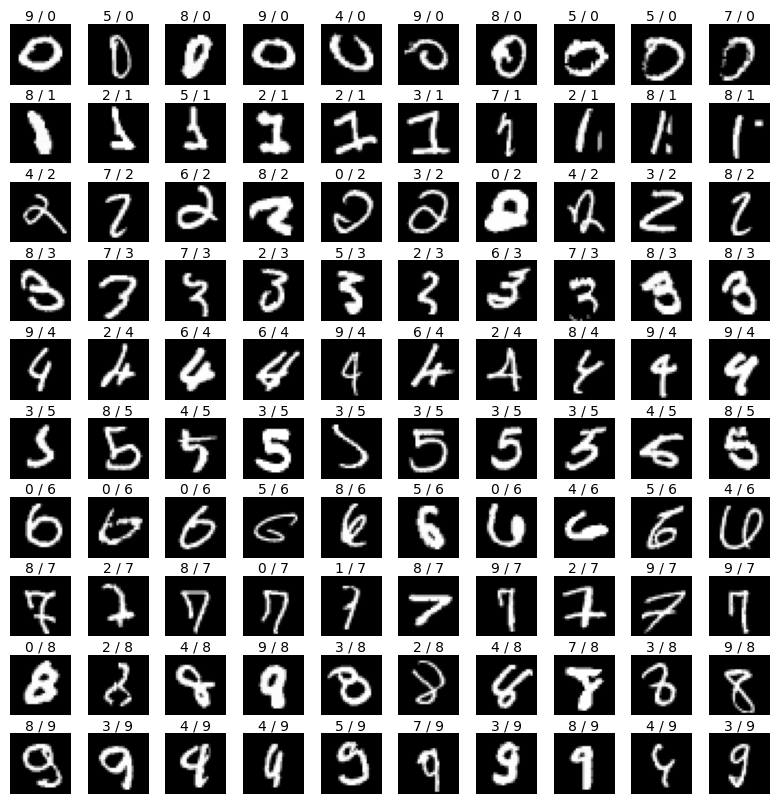

In [ ]:
# 오분류 샘플 시각화
fig, axes = plt.subplots(10, 10, figsize=(10, 10))
plt.subplots_adjust(wspace=0.02, hspace=0.3)

for i in range(10):
    samples = misclassified[i]
    for j in range(10):
        if j < len(samples):
            image, predict = samples[j]
            axes[i, j].imshow(image.squeeze(), cmap="gray")
            axes[i, j].set_title(f"{predict} / {i}", fontsize=10, pad=1)
        axes[i, j].axis("off")

plt.show()

In [ ]:
# 예제 4.2 성능 평가(이진 분류)

# 셋업
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
torch.manual_seed(7)

In [ ]:
# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 데이터셋 준비/전처리
transform = transforms.Compose([transforms.ToTensor(),   # 텐서 변환
                                transforms.Normalize((0.5,), (0.5,))])   # 정규화

train_dataset = datasets.FashionMNIST(root="./data", train=True,
                                      download=True, transform=transform)

test_dataset = datasets.FashionMNIST(root="./data", train=False,
                                     download=True, transform=transform)

print(train_dataset.data.shape)  # 학습 데이터 shape 확인
print(test_dataset.data.shape)  # 테스트 데이터 shape 확인

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


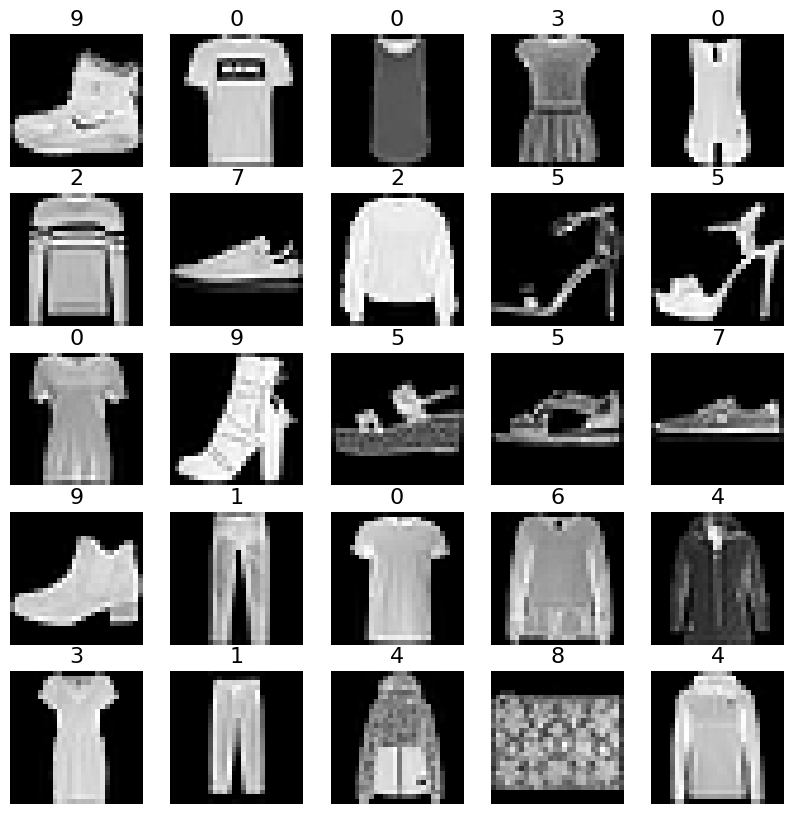

In [ ]:
# 원래의 학습 데이터 시각화
plt.figure(figsize=(10, 10))

for i in range(25):
    image, label = train_dataset[i]

    plt.subplot(5, 5, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(label, fontsize=16)
    plt.axis("off")

plt.show()

In [ ]:
# 레이블 5(sandal)/레이블 7(sneakers) 샘플 추출
mask_train = (train_dataset.targets == 5) | (train_dataset.targets == 7)
mask_test  = (test_dataset.targets == 5) | (test_dataset.targets == 7)

x_train = train_dataset.data[mask_train]
y_train = train_dataset.targets[mask_train]

x_test  = test_dataset.data[mask_test]
y_test  = test_dataset.targets[mask_test]

print(x_train.shape, y_train.shape)  # 추출한 학습 데이터 shape 확인
print(x_test.shape, y_test.shape)  # 추출한 테스트 데이터 shape 확인

torch.Size([12000, 28, 28]) torch.Size([12000])
torch.Size([2000, 28, 28]) torch.Size([2000])


In [ ]:
# 레이블 0/1 재지정
y_train = (y_train == 7).int()
y_test  = (y_test == 7).int()

In [ ]:
# 데이터셋 생성
train_dataset = TensorDataset(x_train.unsqueeze(1).float() / 255.0, y_train)
test_dataset  = TensorDataset(x_test.unsqueeze(1).float() / 255.0, y_test)

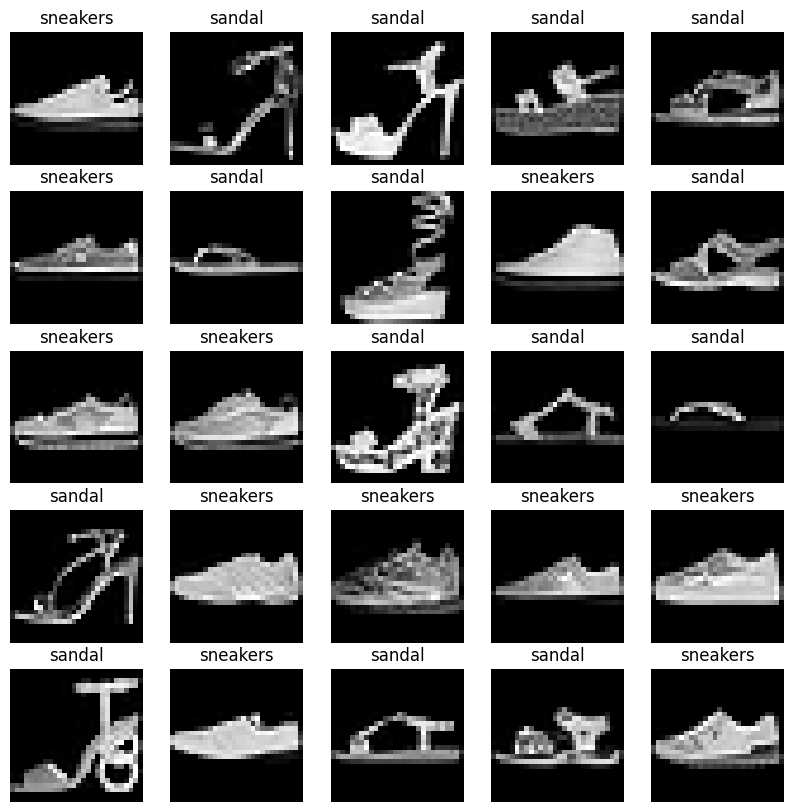

In [ ]:
# 학습 데이터 시각화(클래스명 표시)
class_names = ["sandal", "sneakers"]

plt.figure(figsize=(10, 10))

for i in range(25):
    image, label = train_dataset[i]

    plt.subplot(5, 5, i + 1)
    plt.imshow(image.squeeze().squeeze(), cmap="gray")
    plt.title(class_names[label.item()])   # 레이블(클래스명) 표시
    plt.axis("off")

plt.show()

In [ ]:
# 학습 데이터/검증 데이터 분할
train_size = int(len(train_dataset) * 0.8)
valid_size = len(train_dataset) - train_size

train_dataset, valid_dataset = random_split(
    train_dataset, [train_size, valid_size])

In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# 모델 생성
class FashionMNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 16)
        self.fc2 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

model = FashionMNISTModel().to(device)

In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.BCELoss()   # 손실 함수로 이진 교차 엔트로피 사용
optimizer = optim.Adam(model.parameters(), lr=0.001)   # 옵티마이저로 Adam 사용

In [ ]:
# 학습 함수 정의
def train_step(model, optimizer, loss_fn, train_loader, device):
    model.train()   # 학습 모드

    train_loss = 0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1)
        outputs = model(images)   # 출력 계산
        loss = loss_fn(outputs, labels)   # 손실 계산

        optimizer.zero_grad()   # 그레디언트 초기화
        loss.backward()   # 역전파
        optimizer.step()   # 최적화 수행

        train_loss += loss.item() * images.size(0)

        predict = (outputs >= 0.5).int()   # 예측
        correct += (predict == labels.int()).sum().item()   # 정확한 예측

    train_loss /= len(train_loader.dataset)   # 학습 손실
    train_acc = correct / len(train_loader.dataset)   # 학습 정확도

    return train_loss, train_acc

In [ ]:
# 검증 함수 정의
def validation_step(model, loss_fn, valid_loader, device):
    model.eval()   # 평가 모드

    valid_loss = 0
    correct = 0

    with torch.no_grad():   # 검증할 때에는 자동 미분하지 않음
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            valid_loss += loss.item() * images.size(0)

            predict = (outputs >= 0.5).int()   # 예측
            correct += (predict == labels.int()).sum().item()   # 정확한 예측

    valid_loss /= len(valid_loader.dataset)   # 검증 손실
    valid_acc = correct / len(valid_loader.dataset)   # 검증 정확도

    return valid_loss, valid_acc

In [ ]:
# 모델 학습
epochs = 5

for epoch in range(epochs):
    train_loss, train_acc = train_step(model, optimizer, loss_fn, train_loader,
                                       device)
    valid_loss, valid_acc = validation_step(model, loss_fn, valid_loader, device)

    print(f"Epoch {epoch + 1} / {epochs} \n"
          f" - loss: {train_loss:.4f}  - accuracy: {train_acc:.4f}"
          f" - val_loss: {valid_loss:.4f}  - val_accuracy: {valid_acc:.4f}")

Epoch 1 / 5 
 - loss: 0.2723  - accuracy: 0.8946 - val_loss: 0.1808  - val_accuracy: 0.9325
Epoch 2 / 5 
 - loss: 0.1423  - accuracy: 0.9517 - val_loss: 0.1381  - val_accuracy: 0.9517
Epoch 3 / 5 
 - loss: 0.1203  - accuracy: 0.9582 - val_loss: 0.1388  - val_accuracy: 0.9508
Epoch 4 / 5 
 - loss: 0.1096  - accuracy: 0.9615 - val_loss: 0.1162  - val_accuracy: 0.9575
Epoch 5 / 5 
 - loss: 0.1005  - accuracy: 0.9639 - val_loss: 0.1178  - val_accuracy: 0.9592


In [ ]:
# 모델 평가
model.eval()   # 평가 모드

correct = 0
actual = []
predicted = []

with torch.no_grad():   # 예측할 때에는 자동 미분하지 않음
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predict = (outputs >= 0.5).int().squeeze(1)   # 예측
        correct += (predict == labels).sum().item()   # 정확한 예측

        actual.extend(labels.cpu().numpy())   # 실제값 리스트 생성
        predicted.extend(predict.cpu().numpy())   # 예측값 리스트 생성

test_acc = 100 * correct / len(test_loader.dataset)   # 정확도 계산

print(f"Accuracy: {test_acc:.2f}%")

Accuracy: 95.75%


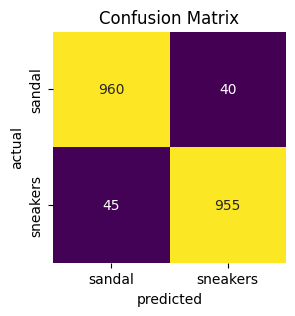

In [ ]:
# 혼동 행렬 시각화
plt.figure(figsize=(3, 3))

cm = confusion_matrix(actual, predicted)

sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", cbar=False,
            xticklabels=["sandal", "sneakers"],
            yticklabels=["sandal", "sneakers"])
plt.title("Confusion Matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()

In [ ]:
# 정확도, 정밀도, 민감도(재현율) 등의 성능 평가 지표 계산
print(f"accuracy: {accuracy_score(actual, predicted):.2f}")   # 정확도
print(f"precision: {precision_score(actual, predicted):.2f}")   # 정밀도
print(f"sensitivity(recall): {recall_score(actual, predicted):.2f}")   #민감도(재현율)
print(f"specificity: {recall_score(actual, predicted, pos_label=0):.2f}")   # 특이도
print(f"f1 score: {f1_score(actual, predicted):.2f}")   # F1 점수
print(f"AUC: {roc_auc_score(actual, predicted):.2f}")   # AUC

accuracy: 0.96
precision: 0.96
sensitivity(recall): 0.95
specificity: 0.96
f1 score: 0.96
AUC: 0.96


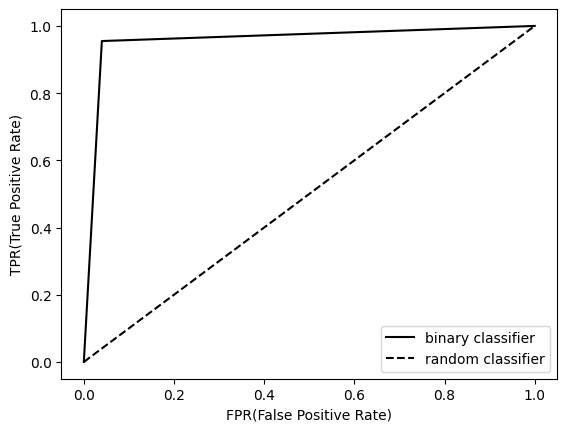

In [ ]:
# ROC 곡선 시각화
fpr, tpr, threshold = roc_curve(actual, predicted)   # FPR과 TPR 값 계산

plt.plot(fpr, tpr, label="binary classifier", color="black")   # ROC 곡선
plt.plot([0, 1], [0, 1], label="random classifier", color="black",
         linestyle="--")
plt.xlabel("FPR(False Positive Rate)")
plt.ylabel("TPR(True Positive Rate)")
plt.legend(loc="lower right")

plt.show()

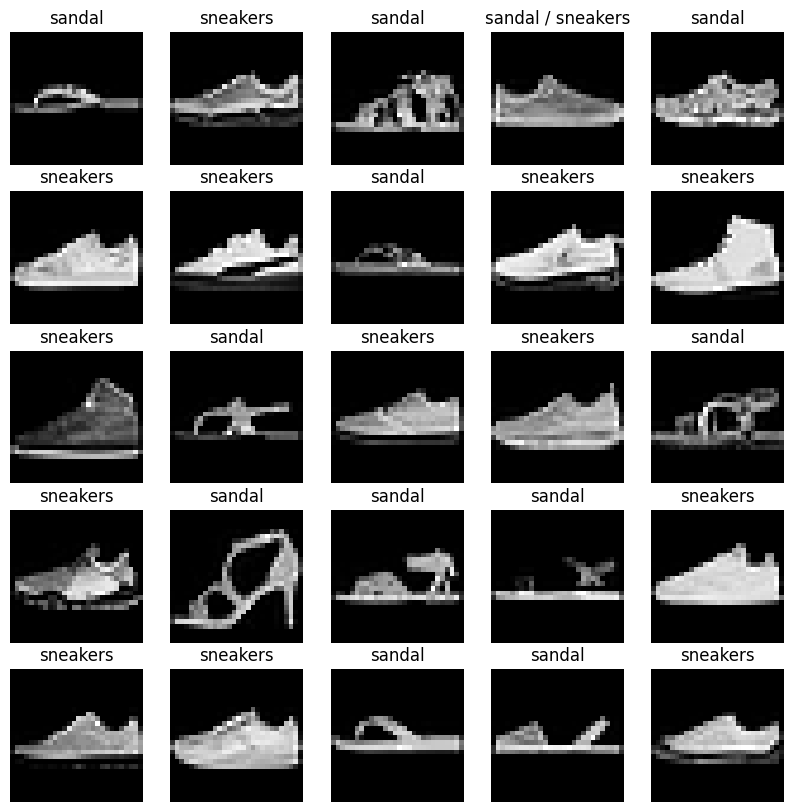

In [ ]:
# 모델 예측 결과 시각화
model.eval()   # 평가 모드

images, labels = next(iter(test_loader))
images = images[:25].to(device)
labels = labels[:25].to(device)

with torch.no_grad():   # 예측할 때에는 자동 미분하지 않음
    outputs = model(images)
    predict = (outputs >= 0.5).int().squeeze(1)

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    if predict[i] != labels[i]:
        plt.title(f"{class_names[predict[i].item()]} / {class_names[labels[i].item()]}")
    else:
        plt.title(class_names[predict[i].item()])
    plt.axis("off")

plt.show()

In [ ]:
# 예제 4.3 선형 회귀

# 셋업
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(77)

In [ ]:
# 데이터 준비
x_train = init.uniform_(torch.Tensor(200, 1), 0, 10)
y_train = (2 * x_train + 1) + init.normal_(torch.FloatTensor(200, 1))

print(x_train.shape, y_train.shape)   # 학습 데이터 shape 확인

torch.Size([200, 1]) torch.Size([200, 1])


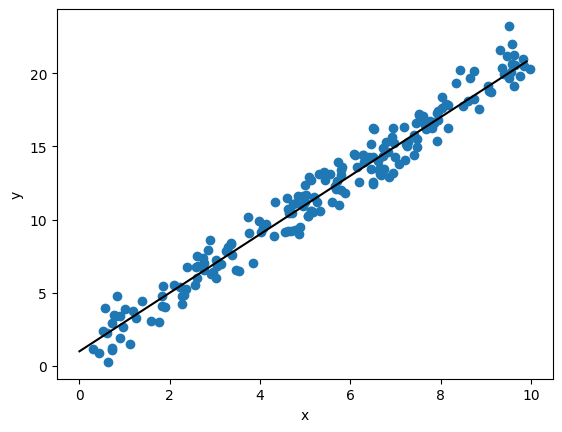

In [ ]:
# 데이터 시각화
x = np.arange(0, 10, 0.1)
y = 2 * x + 1

plt.scatter(x_train, y_train)
plt.plot(x, y, color="black")
plt.xlabel("x")
plt.ylabel("y")

plt.show()

In [ ]:
# 데이터셋 클래스 정의
class CustomgDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):   # 총 샘플 수 반환
        return len(self.x)

    def __getitem__(self, idx):   # 해당 인덱스의 샘플 반환
        x = self.x[idx]
        y = self.y[idx]
        return x, y

In [ ]:
# 데이터셋 생성
dataset = CustomgDataset(x_train, y_train)

In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
# 모델 생성
model = nn.Sequential(
    nn.Linear(1, 1))   # 입력 특징 1개, 출력 뉴런 1개

In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.L1Loss()   # 손실 함수로 평균 절대 오차 사용
optimizer = optim.Adam(model.parameters(),lr=0.1)   # 옵티마이저로 Adam 사용

In [ ]:
# 모델 학습
epochs = 50
losses = []   # 손실 리스트

for epoch in range(epochs):
    train_loss = 0

    for inputs, targets in train_loader:
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)   # 손실 계산

        optimizer.zero_grad()   # 그레디언트 초기화
        loss.backward()   # 역전파
        optimizer.step()   # 최적화 수행

        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)   # 학습 손실
    losses.append(train_loss)  # 손실 저장(학습 결과 시각화용)

    if epoch == 0 or (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1} \t loss: {train_loss:.4f}")

Epoch 1 	 loss: 11.6890
Epoch 10 	 loss: 0.8896
Epoch 20 	 loss: 0.8316
Epoch 30 	 loss: 0.8133
Epoch 40 	 loss: 0.8544
Epoch 50 	 loss: 0.8144


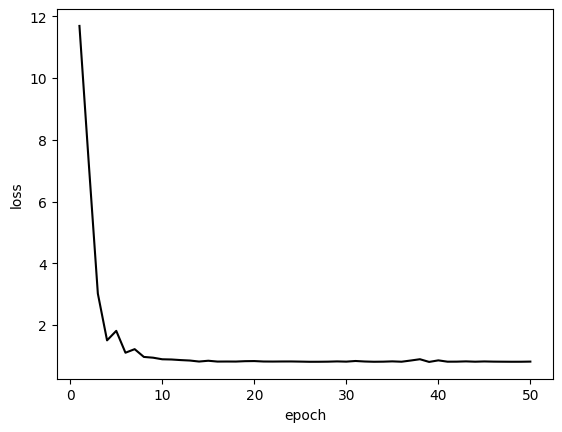

In [ ]:
# 학습 결과 시각화
plt.plot(range(1, epochs + 1), losses, color="black")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

In [ ]:
# 모델 예측
with torch.no_grad():   # 자동 미분하지 않음
    x_test = torch.Tensor([[1], [3], [5], [7]])   # 테스트 입력
    y_test = (2 * x_test + 1)   # 테스트 정답

    predict = model(x_test)   # 예측

    # 예측 결과 확인
    for i in range(4):
        print(f"input: {x_test[i].int().item()} \t"
              f"target: {y_test[i].int().item()} \t"
              f"predict: {predict[i].item():.2f}")

input: 1 	target: 3 	predict: 3.07
input: 3 	target: 7 	predict: 7.09
input: 5 	target: 11 	predict: 11.10
input: 7 	target: 15 	predict: 15.12


In [ ]:
# 학습 후 최종 가중치 확인
weight, bias = model.parameters()

w = weight.detach().numpy()   # 연산 그래프에서 분리하고 배열로 변환
b = bias.detach().numpy()

print(f"weight: {w.round(2)} \n bias: {b.round(2)}")

weight: [[2.01]] 
 bias: [1.06]


In [ ]:
# 예제 4.4  MLP 캘리포니아 주택 가격 예측

# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
torch.manual_seed(7)

In [ ]:
# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 데이터셋 준비
data = fetch_california_housing()

x_train = data.data
y_train = data.target

print(x_train.shape, y_train.shape)   # 학습 데이터 shape 확인
print(data.feature_names)   # 컬럼(특징)명 확인
print(data.target_names)   # 컬럼(정답)명 확인

(20640, 8) (20640,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
['MedHouseVal']


In [ ]:
# 상위 데이터 확인
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target

df.head().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.33,41.0,6.98,1.02,322.0,2.56,37.88,-122.23,4.53
1,8.30,21.0,6.24,0.97,2401.0,2.11,37.86,-122.22,3.58
2,7.26,52.0,8.29,1.07,496.0,2.80,37.85,-122.24,3.52
3,5.64,52.0,5.82,1.07,558.0,2.55,37.85,-122.25,3.41
4,3.85,52.0,6.28,1.08,565.0,2.18,37.85,-122.25,3.42


In [ ]:
# 데이터셋 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
# 데이터 프레임의 인덱싱 예
a = df.loc[0, "HouseAge"]   # 칼럼명 인덱싱
b = df.iloc[0, 1]   # 정수 인덱싱

print(a)
print(b)

41.0
41.0


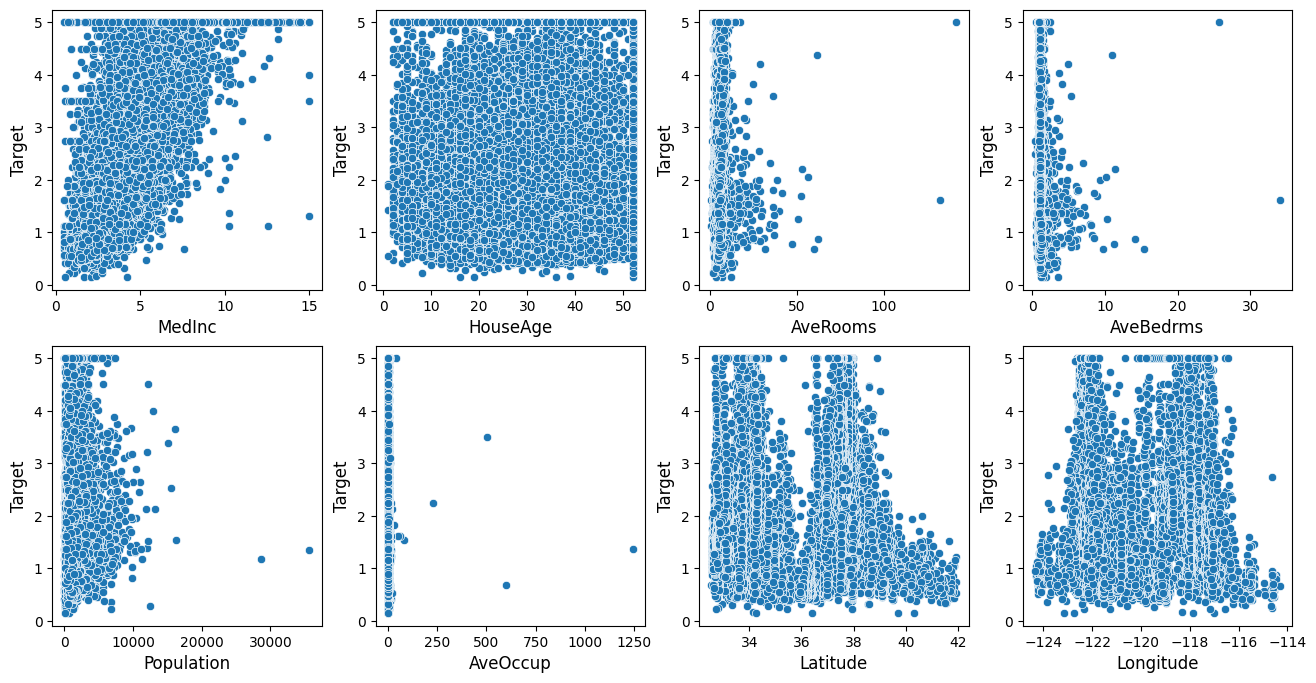

<Axes: xlabel='MedInc', ylabel='Target'>

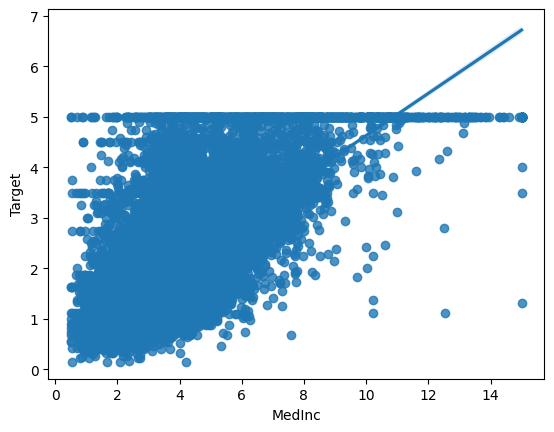

In [ ]:
# 학습 데이터 시각화
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axs = axs.flatten()

for i, feature in enumerate(data.feature_names):
    sns.scatterplot(x=feature, y="Target", data=df, ax=axs[i])   # 산포도

    axs[i].set_xlabel(feature, fontsize=12)
    axs[i].set_ylabel("Target", fontsize=12)

plt.show()

sns.regplot(x="MedInc", y="Target", data=df)   # 선형 회귀

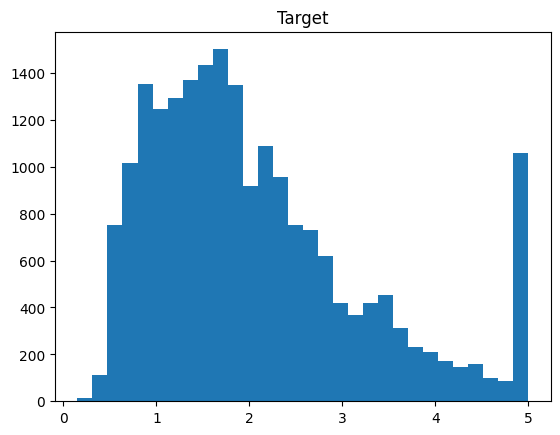

In [ ]:
# 학습 데이터 시각화(히스토그램)
plt.hist(df["Target"], bins=30)
plt.title("Target")

plt.show()

In [ ]:
# 데이터셋 통계 확인
df.describe().loc[['count', 'mean', 'std', 'min', 'max']].round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [ ]:
# 정규화
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

In [ ]:
# 정규화 후 통계 확인
df_scaled = pd.DataFrame(x_train, columns=data.feature_names)
df_scaled["Target"] = y_train

df_scaled.describe().loc[['count', 'mean', 'std', 'min', 'max']].round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,2.07
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.15
min,-1.77,-2.20,-1.85,-1.61,-1.26,-0.23,-1.45,-2.39,0.15
max,5.86,1.86,55.16,69.57,30.25,119.42,2.96,2.63,5.00


In [ ]:
# 학습 데이터/테스트 데이터 분활
x_train, x_test, y_train, y_test = train_test_split(
    x_train, y_train, test_size=0.2, random_state=77)

In [ ]:
# 텐서 변환
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [ ]:
# 데이터셋 생성
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# 모델 생성
class RegressionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = RegressionMLP().to(device)

In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.MSELoss()   # 손실 함수로 평균 제곱 오차  사용
optimizer = optim.Adam(model.parameters(), lr=0.001)   # 옵티마이저로 Adam 사용

In [ ]:
# 모델 학습
epochs = 50
losses = []   # 손실 리스트

for epoch in range(epochs):
    train_loss = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)   # 출력 계산
        loss = loss_fn(outputs, targets)   # 손실 계산

        optimizer.zero_grad()   # 그레디언트 초기화
        loss.backward()   # 역전파
        optimizer.step()   # 최적화 수행

        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)   # 학습 손실
    losses.append(train_loss)  # 손실 저장(학습 결과 시각화용)

    if epoch == 0 or (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1} \t loss: {train_loss:.4f}")

Epoch 1 	 loss: 0.8613
Epoch 10 	 loss: 0.2931
Epoch 20 	 loss: 0.2687
Epoch 30 	 loss: 0.2536
Epoch 40 	 loss: 0.2467
Epoch 50 	 loss: 0.2365


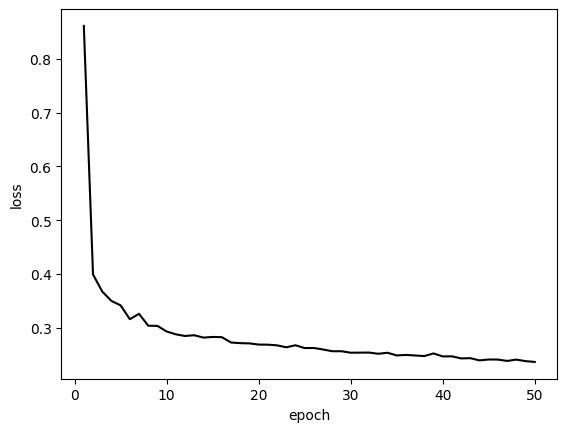

In [ ]:
# 학습 결과 시각화
plt.plot(range(1, epochs + 1), losses, color="black")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

In [ ]:
# 모델 예측
model.eval()   # 평가 모드

x_test, y_test = next(iter(test_loader))
x_test, y_test = x_test.to(device), y_test.to(device)
x_test = x_test[:5]
y_test = y_test[:5]

with torch.no_grad():   # 예측할 때에는 자동 미분하지 않음
    predict = model(x_test)   # 예측

    # 예측 결과 확인
    for i in range(5):
        print(f"target: {y_test[i].item():.2f} \t"
              f"predict: {predict[i].item():.2f}")

target: 3.16 	predict: 2.85
target: 2.55 	predict: 2.53
target: 0.76 	predict: 1.04
target: 3.03 	predict: 2.85
target: 1.34 	predict: 1.65
